## Read data
downloaded from scperturb.org

In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import scipy
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

smoke_test = True
# subsample_frac = 1.
# downsample_frac = 1.

# selected_guides = ["ACTG1_TSS|1", "ACTG1_TSS|2", "ACTB_TSS|1", "ACTB_TSS|2"]
# selected_genes = ["ACTG1"]
# selected_guides = ["TMED10_TSS|1", "TMED10_TSS|2"]
# selected_genes = ["TMED10"]
# selected_guides = ["KRT18_TSS|1", "KRT18_TSS|2"]
# selected_genes = ["KRT18"]
data_dir = "../../../Downloads"
adata_file = f"{data_dir}/GasperiniShendure2019_atscale.h5ad"
adata = ad.read_h5ad(adata_file)


/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
adata.obs.columns
adata.obs["sample"]

AAACCTGAGAGGTACC      1A_1_SI-GA-E2
AAACCTGAGTCAATAG      1A_1_SI-GA-E2
AAACCTGCAAACAACA      1A_1_SI-GA-E2
AAACCTGCACTTCTGC      1A_1_SI-GA-E2
AAACCTGCATGTAGTC      1A_1_SI-GA-E2
                          ...      
TTTGTCAGTACCTACA      2B_8_SI-GA-H9
TTTGTCAGTATCACCA-1    2B_8_SI-GA-H9
TTTGTCAGTTCAGACT-1    2B_8_SI-GA-H9
TTTGTCAGTTCTGTTT      2B_8_SI-GA-H9
TTTGTCATCAAAGTAG-1    2B_8_SI-GA-H9
Name: sample, Length: 207324, dtype: category
Categories (31, object): ['1A_1_SI-GA-E2', '1A_2_SI-GA-E3', '1A_3_SI-GA-E4', '1A_4_SI-GA-E5', ..., '2B_5_SI-GA-H6', '2B_6_SI-GA-H7', '2B_7_SI-GA-H8', '2B_8_SI-GA-H9']

In [3]:
(adata.obs['nperts'] > 1).all()

False

## Read metadata
from gasperini supplement excel file

In [4]:
gasperini_guides = pd.read_excel(
    "../../../Data/gasperini_atscale/mmc2.xlsx", sheet_name=1, na_values=[""]
)
max_grna_length = 19
gasperini_guides["guide"] = gasperini_guides["Spacer"].str.slice(0, 19)
bc_dict = {bc: i for i, bc in enumerate(sorted(gasperini_guides["guide"]))}
gasperini_guides.iloc[49]


Spacer                      TGTTGTGAGAGCATCCGGAG
Target_Site                        non-targeting
chr.candidate_enhancer                       NaN
start.candidate_enhancer                     NaN
stop.candidate_enhancer                      NaN
Category                                     NTC
guide                        TGTTGTGAGAGCATCCGGA
Name: 49, dtype: object

In [5]:
adata = adata[:,['ACTB', 'ACTG1']]
adata


View of AnnData object with n_obs × n_vars = 207324 × 2
    obs: 'sample', 'total_umis', 'Size_Factor', 'gene', 'all_gene', 'barcode', 'read_count', 'umi_count', 'proportion', 'guide_count', 'sample_directory', 'ko_barcode_file', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

<Axes: xlabel='umi_count', ylabel='Count'>

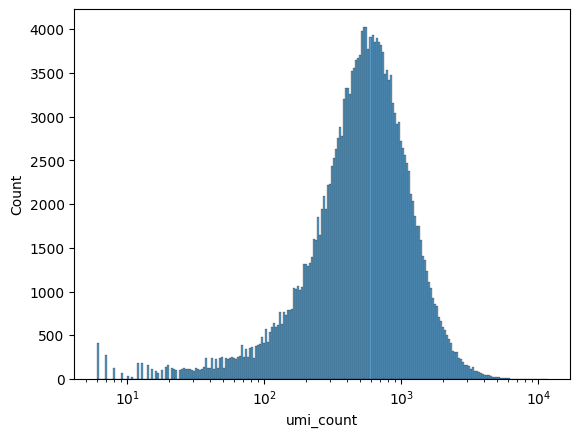

In [6]:
sns.histplot(adata.obs['umi_count'], log_scale=[True, False])

In [7]:
adata = adata[adata.obs['umi_count']>100,:]

In [8]:
adata.obs.columns

Index(['sample', 'total_umis', 'Size_Factor', 'gene', 'all_gene', 'barcode',
       'read_count', 'umi_count', 'proportion', 'guide_count',
       'sample_directory', 'ko_barcode_file', 'id', 'prep_batch',
       'within_batch_chip', 'within_chip_lane', 'percent.mito', 'tissue_type',
       'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype',
       'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts',
       'percent_mito', 'percent_ribo'],
      dtype='object')

## Convert barcode observations to sparse matrix

Text(0.5, 1.0, 'barcode_counts')

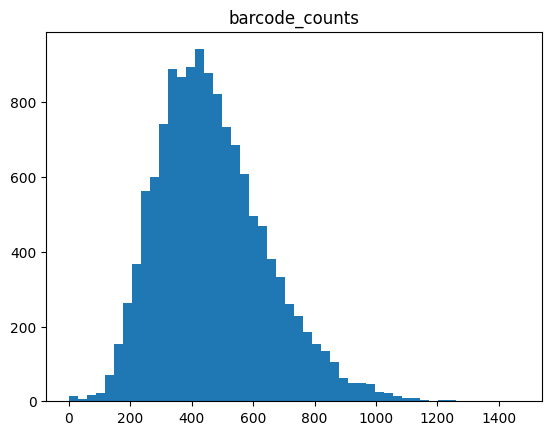

In [9]:
from collections import Counter
import scipy.sparse as sp

bc_counts = Counter({k:0 for k in bc_dict})
split_bcs = adata.obs['barcode'].str.split('_', regex=False)

for bc_list in split_bcs:
    if bc_list[0] != 'nan':
        bc_counts.update([k[:19] for k in bc_list])
    else:
        print("hi")
plt.hist(bc_counts.values(), bins=50)
# plt.axvline(x=cutoff, linestyle="dashed")
plt.title("barcode_counts")


In [10]:
# # adata.obs.iloc[49]
# # first pass: count barcodes
# bc_counts = Counter()
# split_bcs = adata.obs['barcode'].str.split('_', regex=False)
# for bc_list in split_bcs:
#     bc_counts.update(bc_list)
# bc_dict = {k: i for i, k in enumerate(sorted(bc_counts))}
# total_counts = sum(bc_counts.values())
# len(bc_dict)

In [11]:
# second pass: construct sparse array
indices = [] # barcode indices
data = [] # barcode counts
indptr = [0] # column indices for row i are stored in indices[indptr[i]:indptr[i+1]]
for i, bc_list in enumerate(split_bcs):
    assert 'nan' not in bc_list
    bcs_i = Counter(bc_list)
    indptr.append(indptr[i] + len(bcs_i))
    indices+=[bc_dict[bc[:19]] for bc in bcs_i]
    data+=list(bcs_i.values())
assert len(indices) == len(data)

adata.obsm['grna'] = sp.csr_matrix((data, indices, indptr))
# assert adata.obsm['grna'].sum() == total_counts

In [12]:
perturbvi.PERTURBVI.setup_anndata(
    adata,
    'grna',
    batch_key="prep_batch",
    library_size_key="umi_count",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    # size_factor_key="Size_Factor",
)

model = perturbvi.PERTURBVI(adata)
model.view_anndata_setup()


INFO     Generating sequential column names                                                                        


/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/scvi/data/_utils.py:121: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'perturbation_key': 'grna',
│   'layer': None,
│   'batch_key': 'prep_batch',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['percent_mito', 'percent_ribo'],
│   'library_size_key': 'umi_count'
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃    Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch         │   2    │
│         n_cells         │ 193951 │
│ n_extra_continuous_covs │   2    │
│     n_perturbations     │ 13189  │
│         n_vars          │   2    │
└─────────────────────────┴────────┘

                            Data Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃            scvi-tools Location            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.X                  │
│         batch         │         adata.obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.obs['_ind_x']            │
│     perturbations     │            adata.obsm['grna']             │
│      size_factor      │         adata.obs['_size_factor']         │
└───────────────────────┴───────────────────────────────────────────┘

                      batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃  Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['prep_batch'] │ prep_batch_1 │          0          │
│                         │ prep_batch_2 │          1          │
└─────────────────────────┴──────────────┴─────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

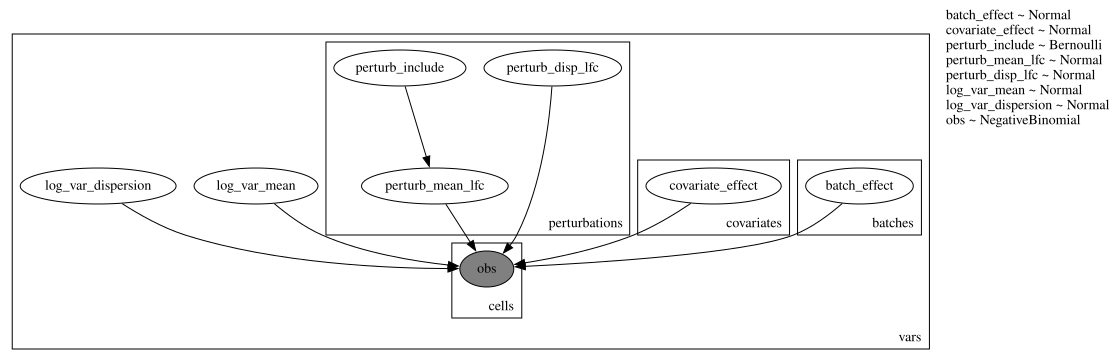

In [13]:
# requires graphviz to be installed
model.render_model()

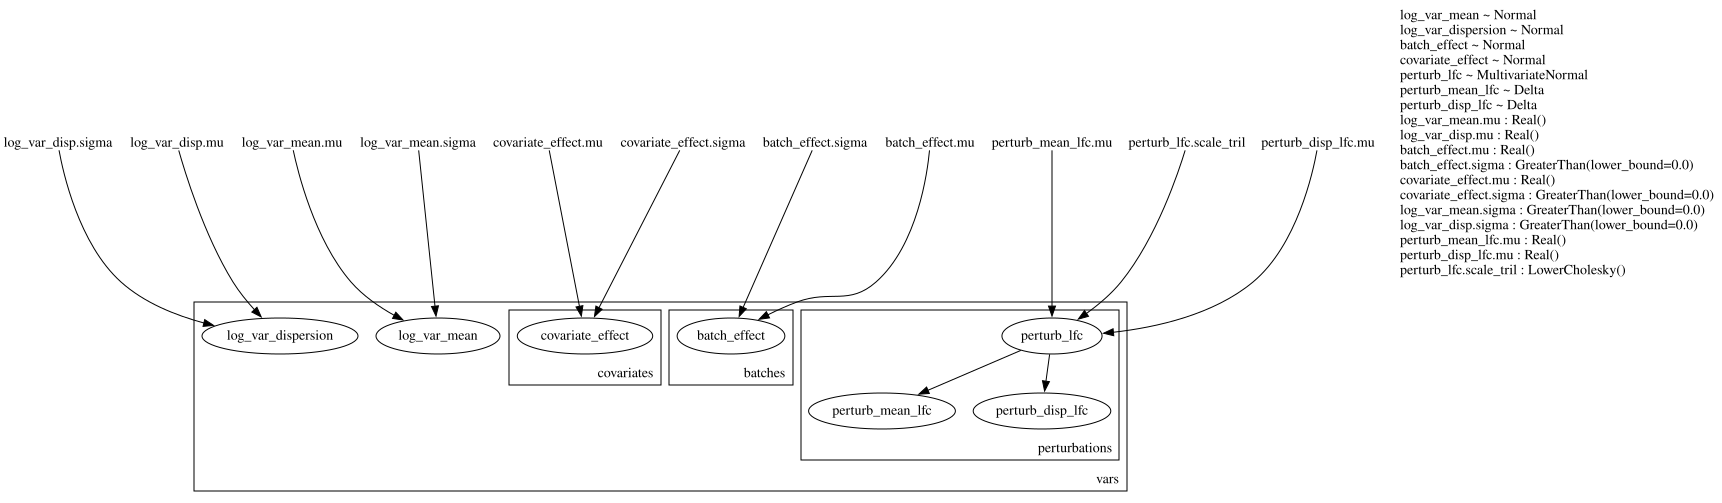

In [14]:
pyro.clear_param_store()

model.render_guide()

## Model training

We can start out with a really high learning rate, then decrease the learning rate to fine-tune


In [15]:
# burn-in
# if smoke_test:
    # model.train(10, lr=0.1, batch_size=1024)
# else:
model.train(20, lr=0.01, batch_size=512)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 20/20: 100%|██████████| 20/20 [05:35<00:00, 16.89s/it, v_num=1, elbo_train=1.79e+6]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [05:35<00:00, 16.80s/it, v_num=1, elbo_train=1.79e+6]


In [16]:
# fine-tuning
model.train(20, lr=1e-3, batch_size=8192)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 20/20: 100%|██████████| 20/20 [02:10<00:00,  6.43s/it, v_num=1, elbo_train=1.67e+6]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [02:10<00:00,  6.53s/it, v_num=1, elbo_train=1.67e+6]


In [17]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)


log_var_mean.mu torch.Size([2])
log_var_disp.mu torch.Size([2])
batch_effect.mu torch.Size([2, 2])
batch_effect.sigma torch.Size([2, 2])
covariate_effect.mu torch.Size([3, 2])
covariate_effect.sigma torch.Size([3, 2])
log_var_mean.sigma torch.Size([2])
log_var_disp.sigma torch.Size([2])
perturb_mean_lfc.mu torch.Size([13189, 2])
perturb_disp_lfc.mu torch.Size([13189, 2])
perturb_lfc.scale_tril torch.Size([13189, 2, 2, 2])


In [18]:
# plt.hist(pyro.get_param_store()["library_size_effect.mu"].cpu().detach().numpy())


In [19]:
%load_ext autoreload
%autoreload 2

selected_genes = adata.var_names
selected_guides = list(bc_dict.keys())
lfc_threshold = -0.1 # ~ at least 10% upreg
# lfc_threshold = 0 # nonzero knockdown
# gene_index=45

# scale_factor = 0.01
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,1,1].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.sf(lfc_threshold, loc=perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
    )
mu_df = make_long_df(perturb_mean_lfc_mu, "mu")
z_df = make_long_df(perturb_z_scores, "z_value")
p_df = make_long_df(perturb_p_vals, "p_value")


In [20]:
scpower_df = pd.merge(z_df, p_df)

# if not smoke_test:
#     scpower_df.to_csv("~/Downloads/all_results.csv")
# significant_results = scpower_df.query("p_value < 1e-8")
# significant_results['element'] = significant_results['guide'].str.split("|", expand=True)[0]
# significant_results
scpower_df.sort_values('z_value').head(10)
scpower_df['guide'] = scpower_df['guide'].str.slice(0, 19)
scpower_df
# guide_gene_pairs = significant_results.groupby(['element','gene'])['guide'].count()
# guide_gene_pairs=guide_gene_pairs[guide_gene_pairs==2]
# guide_gene_pairs.to_excel("~/Downloads/guide_pairs.xlsx")
# # guide_gene_pairs.index
# scpower_df.query("p_value < 1e-3").to_excel("~/Downloads/significant_results.xlsx")
# significant_results['guide'].str.split("_", expand=True)[0]
# significant_results.head(1000).to_excel("~/Downloads/significant_results.xlsx")

,guide,gene,z_value,p_value
0,AAAAAAAAGGTTAAGAGTA,ACTB,0.047329,0.750208
1,AAAAAAAGTCTATTTCCGA,ACTB,-0.275372,0.772422
2,AAAAAATGCGCGTTTCCCC,ACTB,0.793130,0.999992
3,AAAAACACAGAAATACGTG,ACTB,0.586121,0.994038
4,AAAAACTGCACAGTGACTA,ACTB,-1.068759,0.725909
...,...,...,...,...
26373,TTTGTGGTTAGGAATGTCC,ACTG1,0.617181,0.965610
26374,TTTGTTCCAGAACTTTCCA,ACTG1,-0.654950,0.883466
26375,TTTGTTCTCGAGAGAATCC,ACTG1,-1.213882,0.540353
26376,TTTGTTGAGTACCTGCAGC,ACTG1,0.666736,0.978616


In [21]:
merge_df = (
    scpower_df.merge(gasperini_guides, how="left", indicator=True)
    .sort_values("z_value")
    .assign(is_target=lambda x: x["gene"] == x["Target_Site"])
)
merge_df.head(20)
# anti_join = outer_join[~(outer_join._merge == "both")].drop("_merge", axis=1)
# anti_join


,guide,gene,z_value,p_value,Spacer,Target_Site,chr.candidate_enhancer,start.candidate_enhancer,stop.candidate_enhancer,Category,_merge,is_target
996,ACGGGCGGCGGATCGGCAA,ACTB,-14.238869,3.068195e-32,ACGGGCGGCGGATCGGCAA,ACTB,NaN,NaN,NaN,TSS,both,True
14769,AGAGTGCGAGAGCTGGCAG,ACTG1,-11.164384,1.881059e-20,AGAGTGCGAGAGCTGGCAG,ACTG1,NaN,NaN,NaN,TSS,both,True
16268,CACCGGCAGAGAAACGCGA,ACTG1,-11.142121,5.370406e-23,CACCGGCAGAGAAACGCGA,ACTG1,NaN,NaN,NaN,TSS,both,True
245,AAGCCCGGCCAGCCGACCG,ACTB,-8.029640,1.662103e-08,AAGCCCGGCCAGCCGACCG,ACTB,NaN,NaN,NaN,TSS,both,True
25974,TTATTGCTTAAGCCAGAGG,ACTG1,-5.619500,1.053977e-03,TTATTGCTTAAGCCAGAGGT,chr12.4672,chr12,125117896.0,125118618.0,candidate_enhancer:picked_by_exploratory_submo...,both,False
24137,TCCCAGCTGAGAAAACTGA,ACTG1,-5.399245,2.937344e-03,TCCCAGCTGAGAAAACTGAA,chr14.1986,chr14,93598914.0,93599083.0,candidate_enhancer:picked_by_exploratory_submo...,both,False
1290,AGAAACCTTGATGCGTAGG,ACTB,-4.858745,5.467442e-03,AGAAACCTTGATGCGTAGGG,chr8.3119,chr8,126395829.0,126396462.0,candidate_enhancer:picked_by_model_built_from_...,both,False
17764,CTACAGCAAGGACATAGCC,ACTG1,-4.838190,3.953073e-03,CTACAGCAAGGACATAGCCA,chr6.327,chr6,4987260.0,4987614.0,candidate_enhancer:picked_by_model_built_from_...,both,False
26110,TTGCCTATTCATTTCCAAA,ACTG1,-4.812404,6.077195e-03,TTGCCTATTCATTTCCAAAG,chr14.2283,chr14,101150765.0,101150851.0,candidate_enhancer:picked_by_model_built_from_...,both,False
25665,TTAATGAGTCACCACTTAA,ACTG1,-4.787724,3.882869e-04,TTAATGAGTCACCACTTAAG,chr18.91,chr18,3015291.0,3015623.0,candidate_enhancer:picked_by_model_built_from_...,both,False


[]

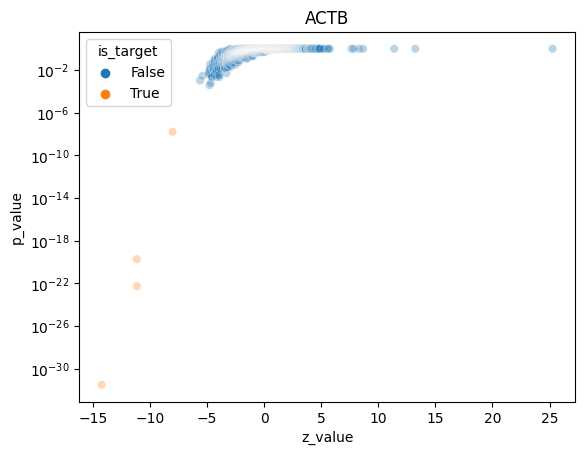

In [22]:
sns.scatterplot(
    merge_df,
    hue="is_target",
    x="z_value",
    y="p_value",
    alpha=0.3
)
if smoke_test:
    plt.title(selected_genes[0])

plt.semilogy()
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))


In [23]:
import matplotlib.pyplot as plt

# plt.scatter(pyro.get_param_store()["log_var_mean.mu"].cpu().detach().numpy(), pyro.get_param_store()["log_var_disp.mu"].cpu().detach().numpy(), alpha=0.1)


## Compare to SCEPTRE results


In [24]:
# merge_df=merge_df.assign(residual = lambda x: x['z_value']-x['value'])
# merge_df.sort_values('residual').tail(20)


In [25]:
import matplotlib.pyplot as plt

# merge_df = pd.merge(sceptre_df, scpower_df, how="inner")

sns.scatterplot(merge_df, x="SCEPTRE_p_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.3)
plt.semilogx()

# plt.xlim([-40, 20])
# plt.ylim([-40, 20])

ValueError: Could not interpret value `SCEPTRE_p_value` for parameter `x`

<Axes: xlabel='z_value', ylabel='SCEPTRE_z_value'>

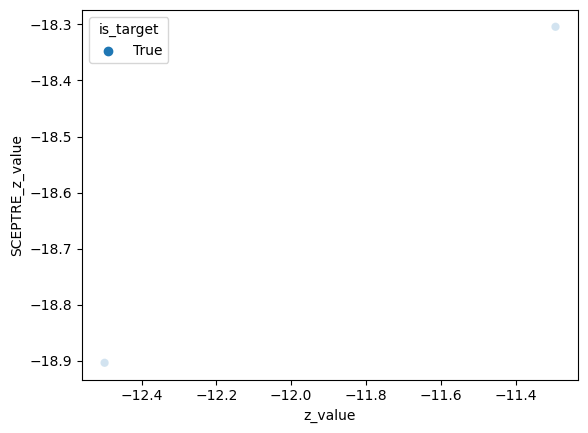

In [ ]:
sns.scatterplot(merge_df, x="z_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.2)


(1e-20, 2)

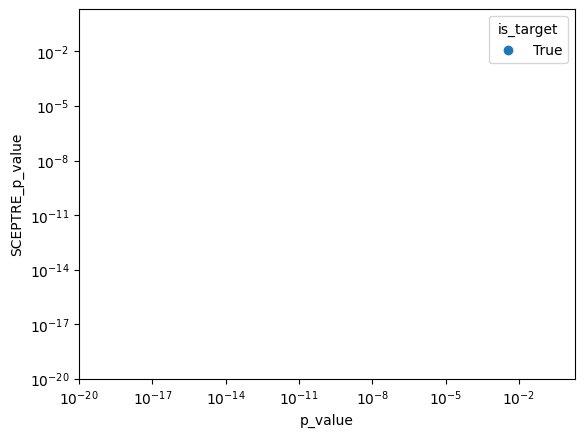

In [ ]:
sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="is_target", alpha=0.3)
plt.loglog()
plt.xlim(1e-20, 2)
plt.ylim(1e-20, 2)

plot some genes


['KRT18_TSS|1', 'KRT18_TSS|2']
KRT18 KRT18_TSS|1


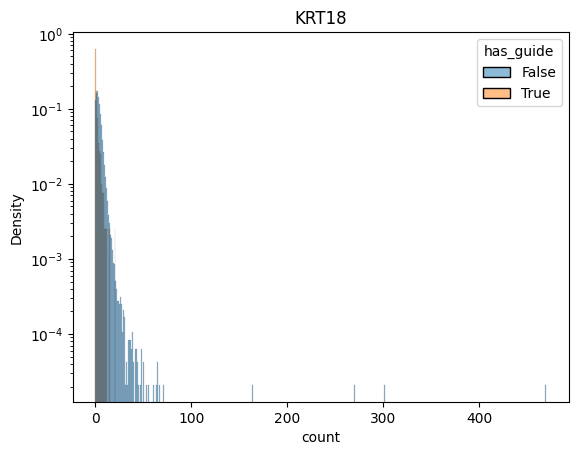

KRT18 KRT18_TSS|2


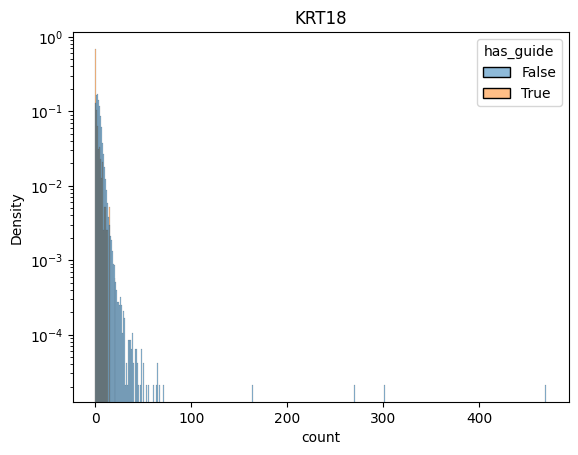

In [ ]:
import scanpy as sc

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"
# guide_1 = "TMED10_TSS|1"
# guide_2 = "TMED10_TSS|2"


print(selected_guides)
# plot_genes = selected_genes
# plot_gene = selected_genes
# plot_genes = ["TMED10","KDELR2","KDELR3","SEC13", "YIF1A"]
for plot_gene in selected_genes:
    for plot_guide in selected_guides:
        print(plot_gene, plot_guide)
        counts = mdata["rna"][:, plot_gene].X.todense().A1
        guide_1_obs = mdata["grna"][:, plot_guide].X.astype(bool).squeeze()

        plot_df = pd.DataFrame({"count": counts, "has_guide": guide_1_obs})
        sns.histplot(
            plot_df,
            x="count",
            hue="has_guide",
            binwidth=1,
            common_norm=False,
            stat="density",
        )
        plt.semilogy()
        # plt.xlim(0, 50)
        plt.title(plot_gene)
        plt.show()


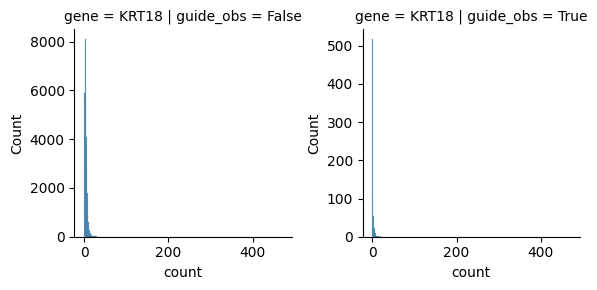

In [ ]:
counts_df = mdata["rna"][:, selected_genes].to_df()
guide_obs = mdata["grna"][:, selected_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, row="gene", col="guide_obs",sharey=False)
g.map_dataframe(sns.histplot, x="count", binwidth=1, hue_order=[False,True])


# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()

